<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 159.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 144.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-08-31 18:16:48--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  3.89MB/s    in 43s     

2026-08-31 18:17:32 (3.51 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



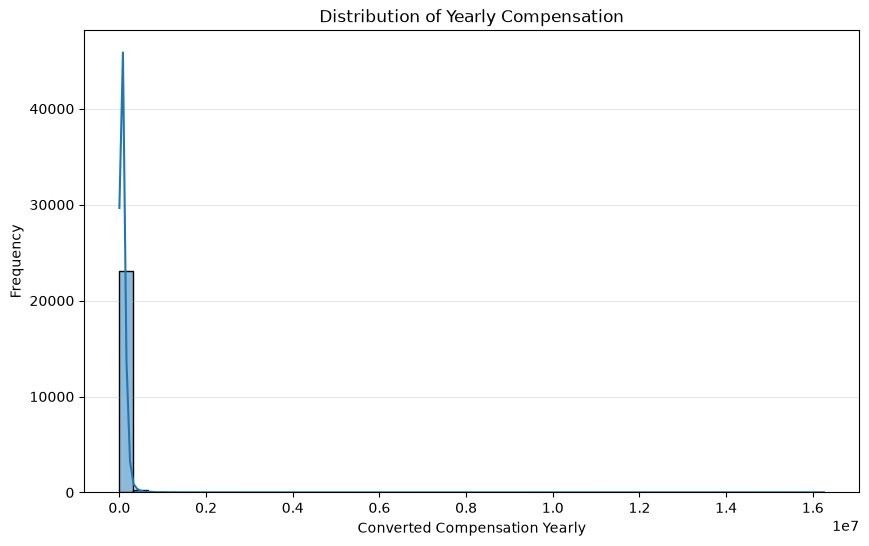

In [5]:
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['ConvertedCompYearly'].dropna(), bins=50, kde=True)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [4]:
df['Age_numeric'] = df['Age'].str.extract(r'(\d+)').astype(float)

# Построение Box Plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age_numeric'])
plt.title('Box Plot of Age')
plt.xlabel('Age (Numeric)')
plt.show()

NameError: name 'sns' is not defined

<Figure size 800x400 with 0 Axes>

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



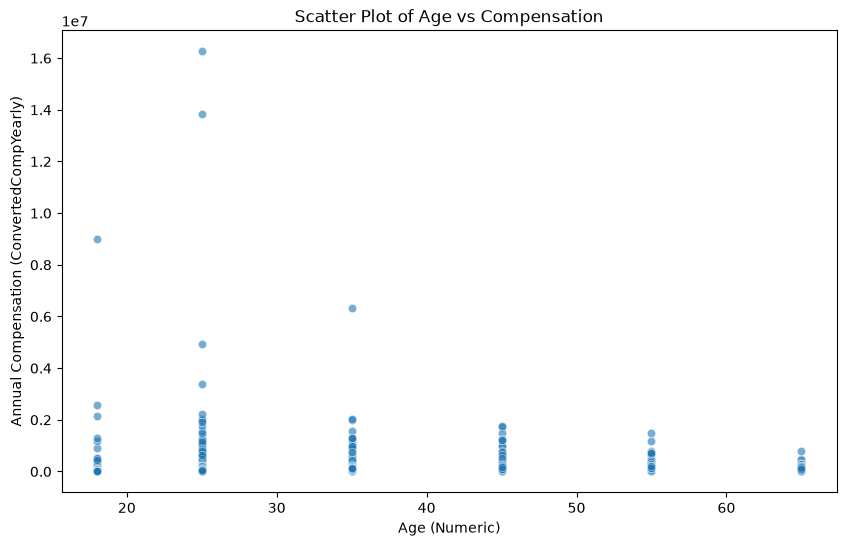

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age_numeric', y='ConvertedCompYearly', alpha=0.6)
plt.title('Scatter Plot of Age vs Compensation')
plt.xlabel('Age (Numeric)')
plt.ylabel('Annual Compensation (ConvertedCompYearly)')
plt.show()


##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


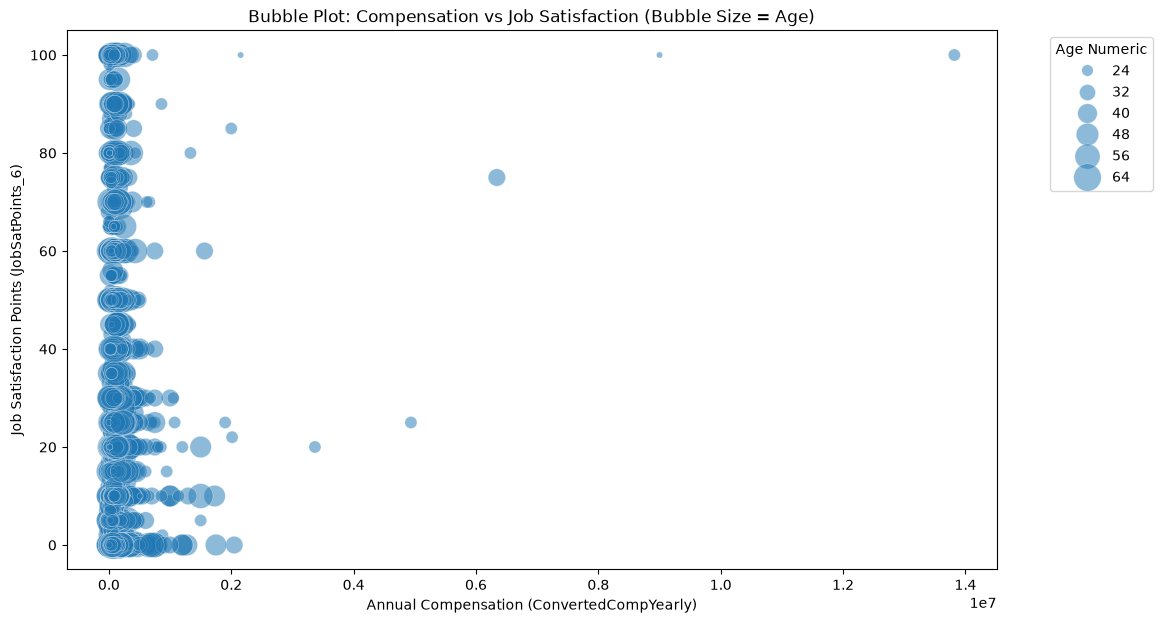

In [9]:
plt.figure(figsize=(12, 7))
# Создаем пузырьковую диаграмму, задав размер через параметр size
sns.scatterplot(data=df, x='ConvertedCompYearly', y='JobSatPoints_6', 
                size='Age_numeric', sizes=(20, 400), alpha=0.5, legend='brief')

plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Annual Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction Points (JobSatPoints_6)')
plt.legend(title='Age Numeric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



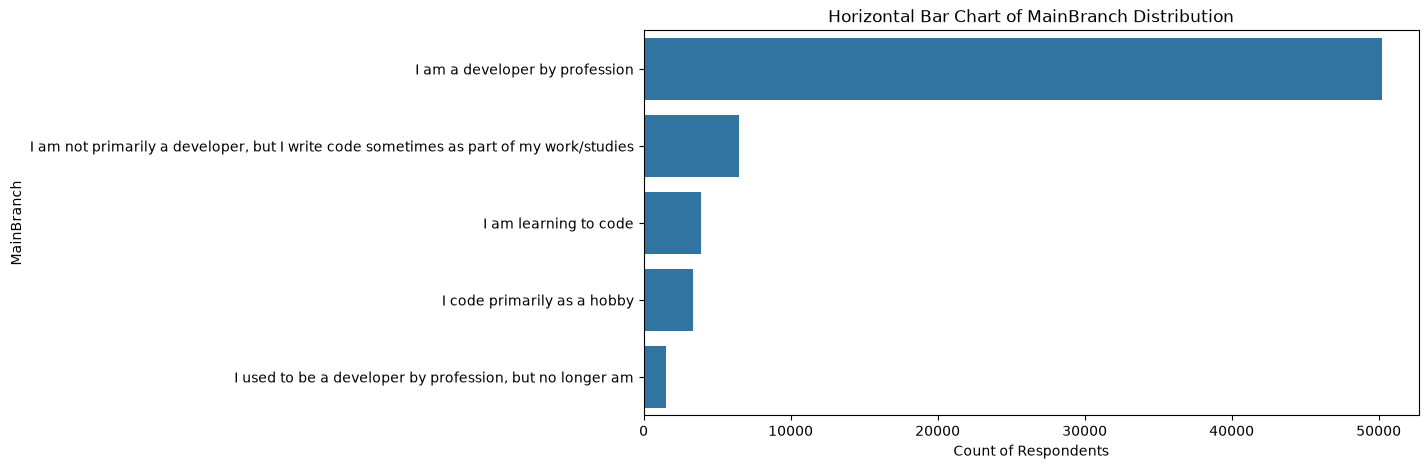

In [8]:
plt.figure(figsize=(10, 5))
main_branch_counts = df['MainBranch'].value_counts()

# Построение горизонтального графика (параметр orient='h')
sns.barplot(x=main_branch_counts.values, y=main_branch_counts.index, orient='h')
plt.title('Horizontal Bar Chart of MainBranch Distribution')
plt.xlabel('Count of Respondents')
plt.ylabel('MainBranch')
plt.show()


##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



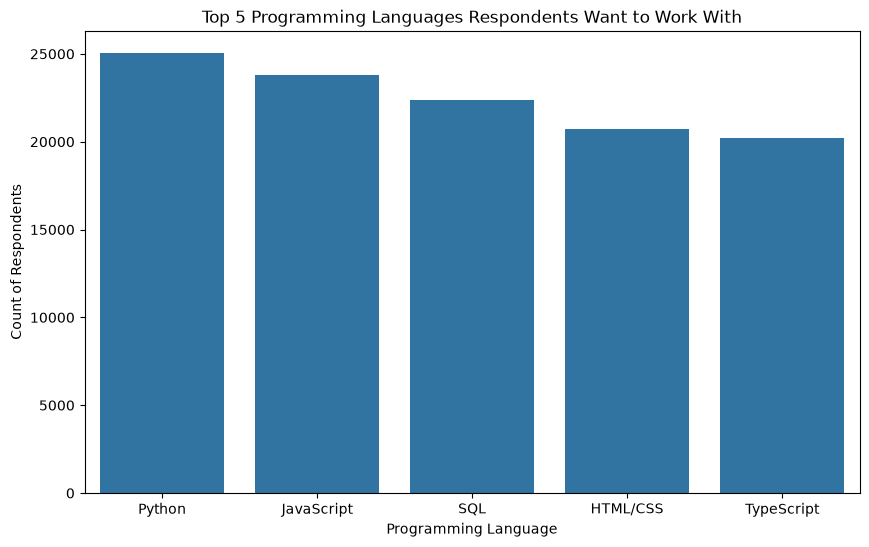

In [10]:
plt.figure(figsize=(10, 6))

# Разделяем строки с языками по символу ";" и берем топ-5 самых частых
top_5_languages = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts().head(5)

# Построение вертикального графика
sns.barplot(x=top_5_languages.index, y=top_5_languages.values)
plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Count of Respondents')
plt.show()


##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


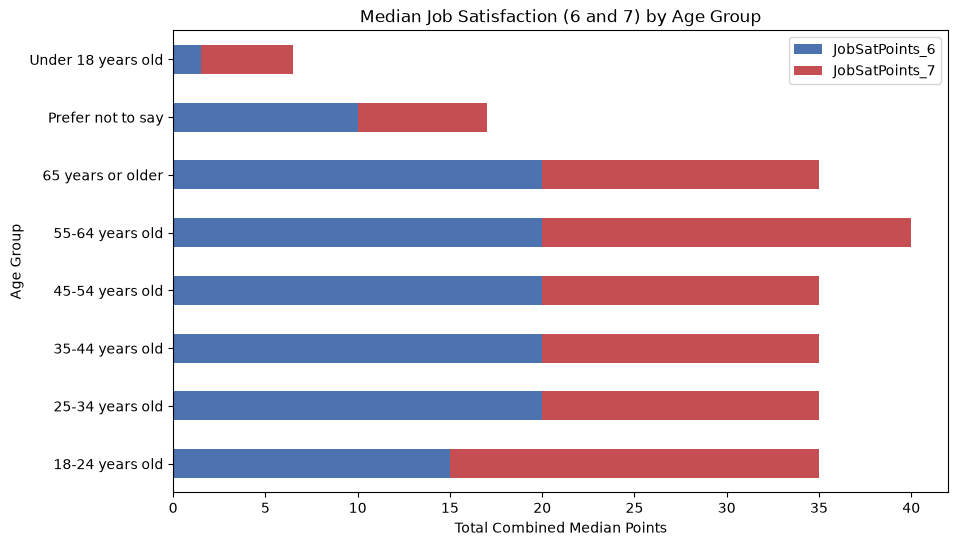

In [7]:
job_sat_median = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Построение накопительной диаграммы (stacked bar)
job_sat_median.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#4c72b0', '#c44e52'])
plt.title('Median Job Satisfaction (6 and 7) by Age Group')
plt.xlabel('Total Combined Median Points')
plt.ylabel('Age Group')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



/tmp/ipykernel_386/3511780380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=db_counts.values, y=db_counts.index, palette='viridis')

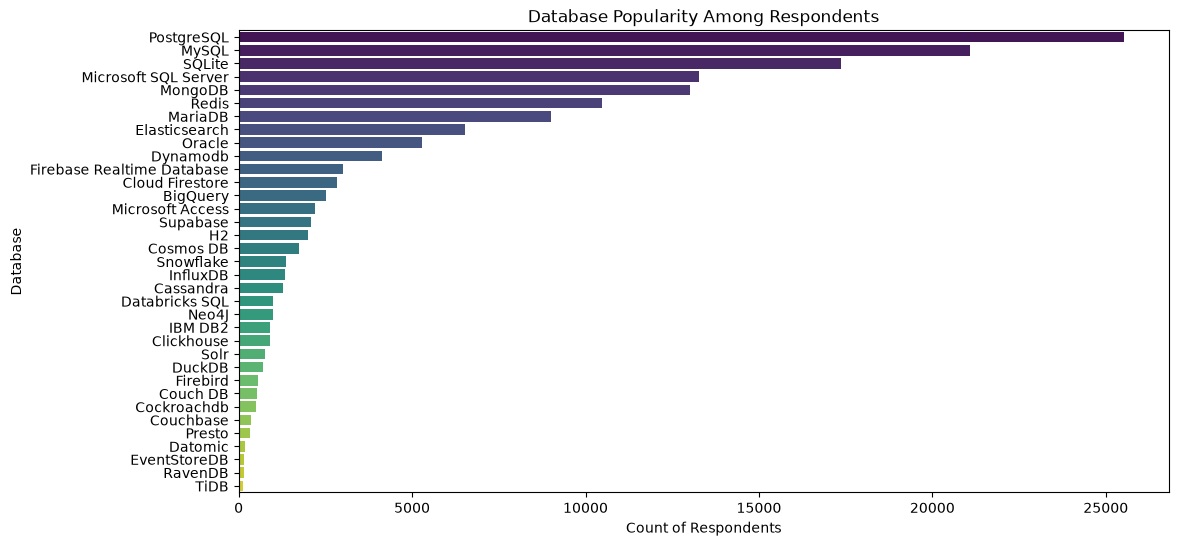

In [11]:
plt.figure(figsize=(12, 6))

# Разделяем базы данных и подсчитываем количество упоминаний
db_counts = df['DatabaseHaveWorkedWith'].str.split(';').explode().value_counts()

# Строим график популярности баз данных
sns.barplot(x=db_counts.values, y=db_counts.index, palette='viridis')
plt.title('Database Popularity Among Respondents')
plt.xlabel('Count of Respondents')
plt.ylabel('Database')
plt.show()


/tmp/ipykernel_386/160569946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=current_db.values, y=current_db.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_386/160569946.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=next_year_db.values, y=next_year_db.index, ax=axes[1], palette='Oranges_r')

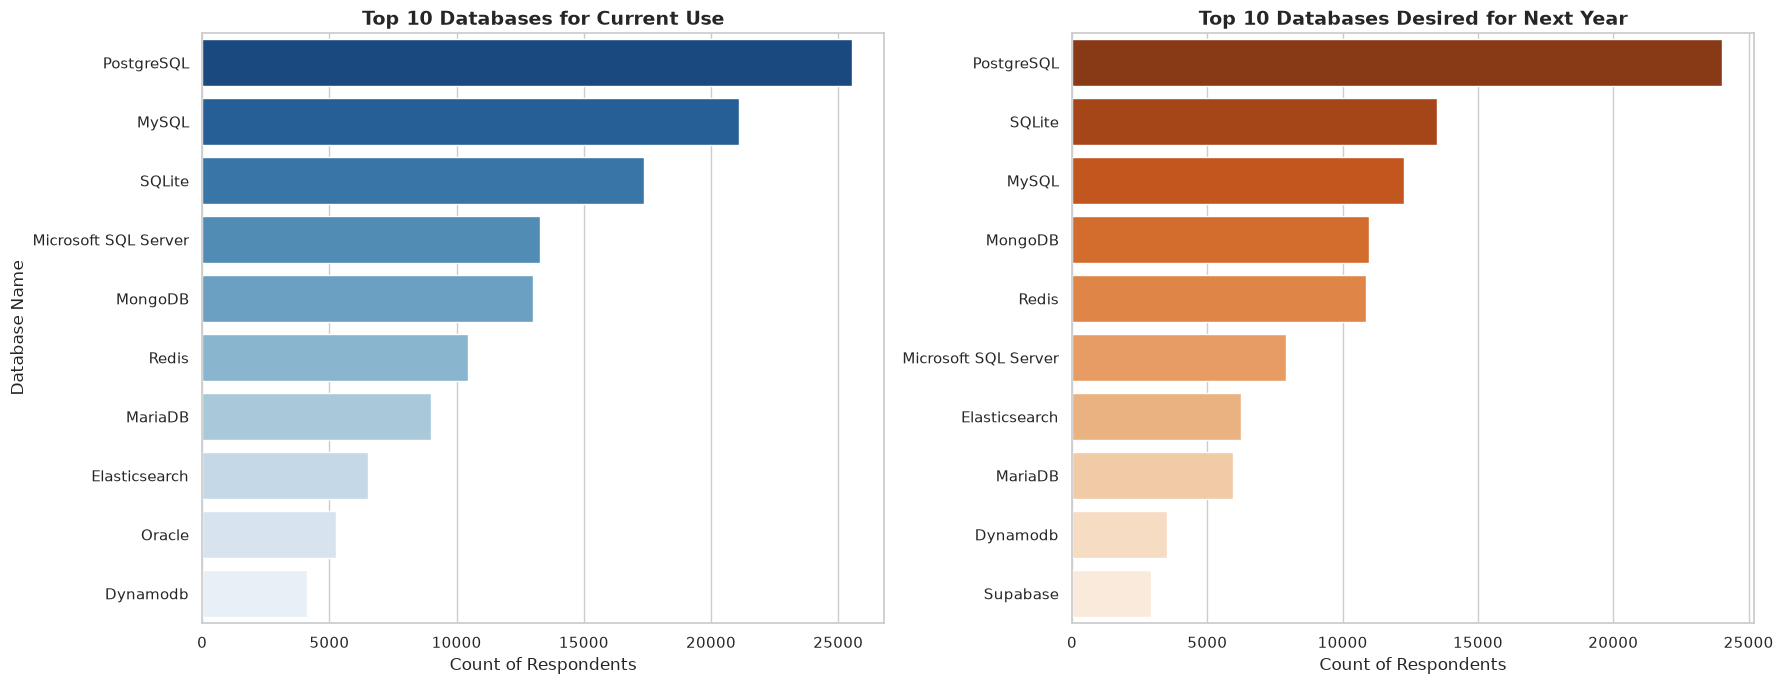

--- TOP 10 DATABASES: CURRENT USE ---
DatabaseHaveWorkedWith
PostgreSQL              25536
MySQL                   21099
SQLite                  17365
Microsoft SQL Server    13275
MongoDB                 13007
Redis                   10463
MariaDB                  8991
Elasticsearch            6533
Oracle                   5273
Dynamodb                 4138
Name: count, dtype: int64

--- TOP 10 DATABASES: NEXT YEAR ---
DatabaseWantToWorkWith
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Dynamodb                 3503
Supabase                 2930
Name: count, dtype: int64

In [14]:

# Настраиваем стиль графиков
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Топ-10 баз данных для текущего использования (Current Use)
current_db = df['DatabaseHaveWorkedWith'].str.split(';').explode().value_counts().head(10)
sns.barplot(x=current_db.values, y=current_db.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Databases for Current Use', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count of Respondents')
axes[0].set_ylabel('Database Name')

# 2. Топ-10 баз данных на следующий год (Next Year Desired)
next_year_db = df['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().head(10)
sns.barplot(x=next_year_db.values, y=next_year_db.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 Databases Desired for Next Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count of Respondents')
axes[1].set_ylabel('')  # Убираем дублирующуюся подпись оси Y

plt.tight_layout()
plt.show()

# Дополнительно выведем текстовый результат в консоль
print("--- TOP 10 DATABASES: CURRENT USE ---")
print(current_db)
print("\n--- TOP 10 DATABASES: NEXT YEAR ---")
print(next_year_db)


### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



/tmp/ipykernel_386/1327396561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_comp, x='Age', y='ConvertedCompYearly', palette='muted')

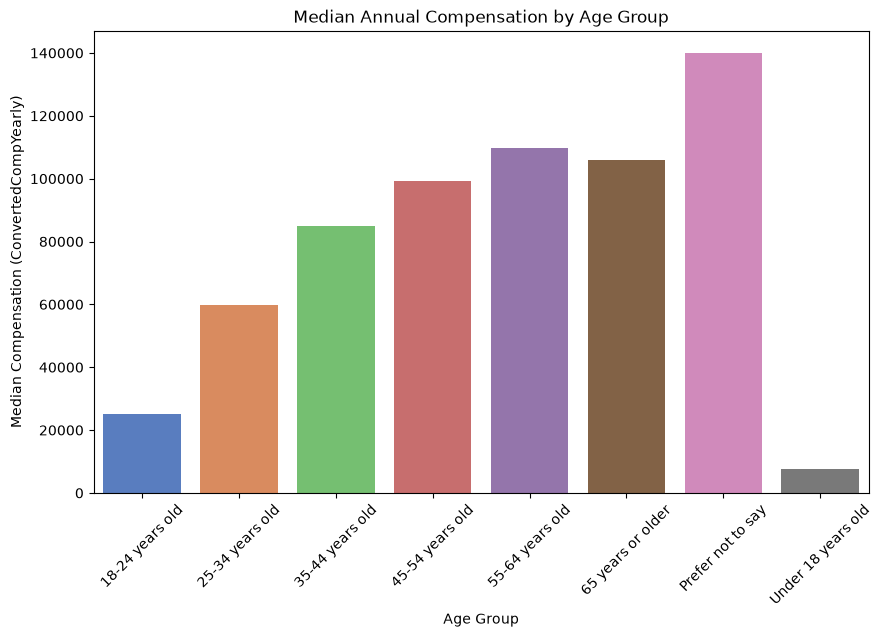

In [12]:
plt.figure(figsize=(10, 6))

# Находим медиану компенсации по возрастным группам
median_comp = df.groupby('Age')['ConvertedCompYearly'].median().reset_index()

# Строим сгруппированную диаграмму
sns.barplot(data=median_comp, x='Age', y='ConvertedCompYearly', palette='muted')
plt.title('Median Annual Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation (ConvertedCompYearly)')
plt.xticks(rotation=45)
plt.show()


##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



/tmp/ipykernel_386/2293286174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')

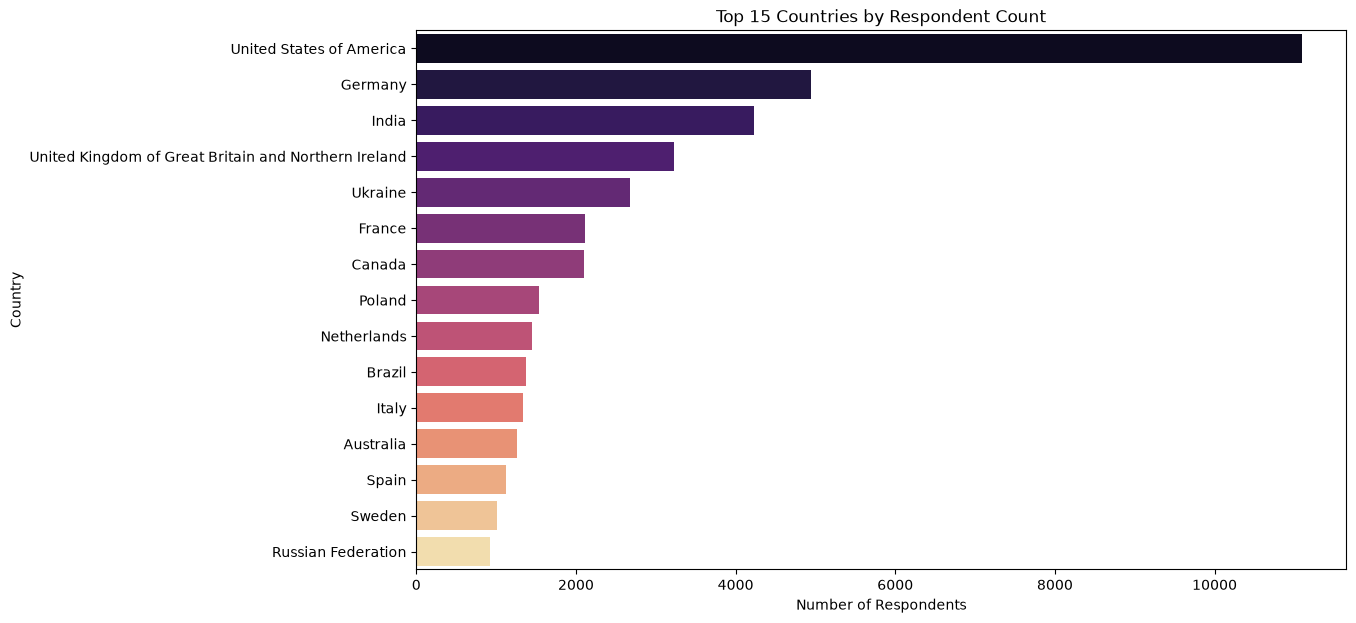

In [13]:
plt.figure(figsize=(12, 7))

# Подсчитываем топ-15 стран по количеству респондентов
top_countries = df['Country'].value_counts().head(15)

# Строим диаграмму
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 15 Countries by Respondent Count')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.show()


### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
